# Project 03: Psycholinguistic Data Wrangling & EDA
**Processing Large-Scale Lexical Decision Data (Inspired by the English Lexicon Project)**

## 1. Project Objective
Real-world psycholinguistic data is inherently noisy. This project demonstrates practical **data wrangling, cleaning, and Exploratory Data Analysis (EDA)** skills using a dataset modeled after the **English Lexicon Project (ELP)**. 

The objective is to take raw, messy behavioral data (containing missing values, extreme outliers, and low-accuracy trials) and build a robust Python pipeline to clean it, followed by visualizing the classic **Word Length Effect** and **Morphological Complexity Effect** on Reaction Times (RT).

## 2. Technical Stack
*   **Data Wrangling:** `pandas`, `numpy` (Handling NaNs, Z-score trimming, Boolean masking)
*   **Data Visualization:** `seaborn`, `matplotlib` (Regression plots, distributions)

## 3. Reference & Data Inspiration
*   **Balota, D. A., Yap, M. J., Cortese, M. J., Hutchison, K. A., Kessler, B., Loftis, B., ... & Treiman, R. (2007).** The English Lexicon Project. *Behavior Research Methods*, 39(3), 445-459.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Simulate a "Messy" Raw Dataset (Inspired by ELP)
# In reality, this would be pd.read_csv('elp_raw_data.csv')
np.random.seed(42)
n_words = 5000

# Generate psycholinguistic variables
word_length = np.random.randint(3, 13, n_words)
# Longer words tend to have more morphemes
n_morphemes = np.where(word_length > 6, np.random.randint(1, 4, n_words), 1) 

# Generate RT with natural word length and morpheme effects + noise
rt = 400 + (word_length * 25) + (n_morphemes * 15) + np.random.normal(0, 60, n_words)
accuracy = np.random.uniform(0.4, 1.0, n_words)

# Inject "Messiness" (Nulls, Extreme Outliers, errors)
rt[np.random.choice(n_words, 150, replace=False)] = np.nan # Missing RTs
rt[np.random.choice(n_words, 50, replace=False)] = 9999    # Equipment error outliers
accuracy[np.random.choice(n_words, 100, replace=False)] = np.nan # Missing accuracy

# Create Raw DataFrame
df_raw = pd.DataFrame({
    'Word_ID': [f'W_{i:04d}' for i in range(n_words)],
    'Length': word_length,
    'N_Morph': n_morphemes,
    'I_Mean_RT': rt,
    'I_Mean_Accuracy': accuracy
})

print("🚨 [RAW DATA STAGE] 🚨")
print(f"Initial Raw Data Shape: {df_raw.shape}")
print("Missing Values per Column:")
print(df_raw.isnull().sum())

🚨 [RAW DATA STAGE] 🚨
Initial Raw Data Shape: (5000, 5)
Missing Values per Column:
Word_ID              0
Length               0
N_Morph              0
I_Mean_RT          150
I_Mean_Accuracy    100
dtype: int64


## 3. Data Cleaning Pipeline
In cognitive psychology, it is standard practice to:
1. Remove trials with missing data (NaNs).
2. Filter out words with low mean accuracy (e.g., < 70%).
3. Remove extreme RT outliers (e.g., hardware errors like 9999ms).
4. Trim statistical outliers (RTs beyond ±2.5 Standard Deviations).

In [2]:
# 2. Execute Data Cleaning Pipeline
df_clean = df_raw.copy()

# Step 1: Drop missing values (NaN)
df_clean = df_clean.dropna(subset=['I_Mean_RT', 'I_Mean_Accuracy'])

# Step 2: Filter low accuracy words (Keep only words recognized > 70% of the time)
df_clean = df_clean[df_clean['I_Mean_Accuracy'] >= 0.70]

# Step 3: Remove impossible RTs (e.g., > 3000ms or < 200ms)
df_clean = df_clean[(df_clean['I_Mean_RT'] > 200) & (df_clean['I_Mean_RT'] < 3000)]

# Step 4: Trim statistical outliers (Z-score approach)
df_clean['RT_Z'] = (df_clean['I_Mean_RT'] - df_clean['I_Mean_RT'].mean()) / df_clean['I_Mean_RT'].std()
df_clean = df_clean[np.abs(df_clean['RT_Z']) < 2.5]

print("✨ [CLEAN DATA STAGE] ✨")
print(f"Cleaned Data Shape: {df_clean.shape}")
print(f"Total words removed during cleaning: {len(df_raw) - len(df_clean)}")

✨ [CLEAN DATA STAGE] ✨
Cleaned Data Shape: (2311, 6)
Total words removed during cleaning: 2689


## 4. Exploratory Data Analysis (EDA)
Visualizing the fundamental psycholinguistic effects: **Word Length Effect** (longer words take more time to process) grouped by **Morphological Complexity** (number of morphemes).

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_13388\2773583746.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='N_Morph', y='I_Mean_RT', data=df_clean, palette="Set2")


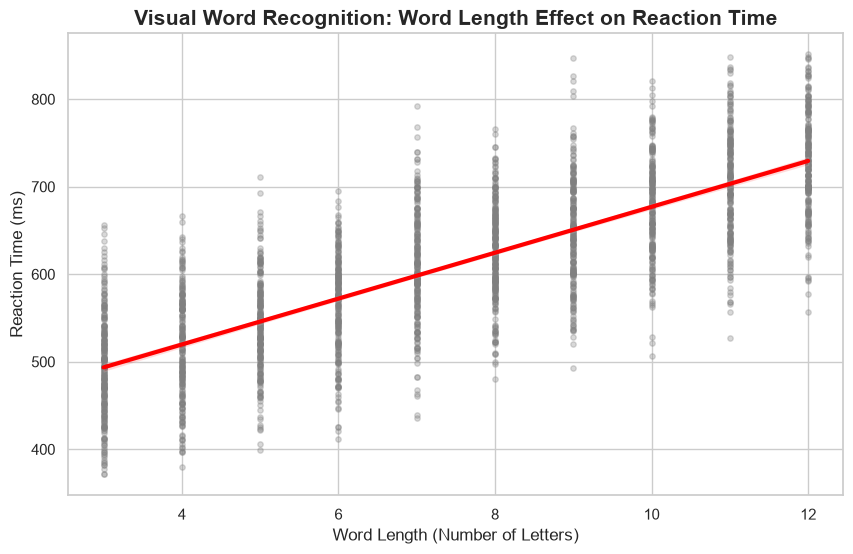

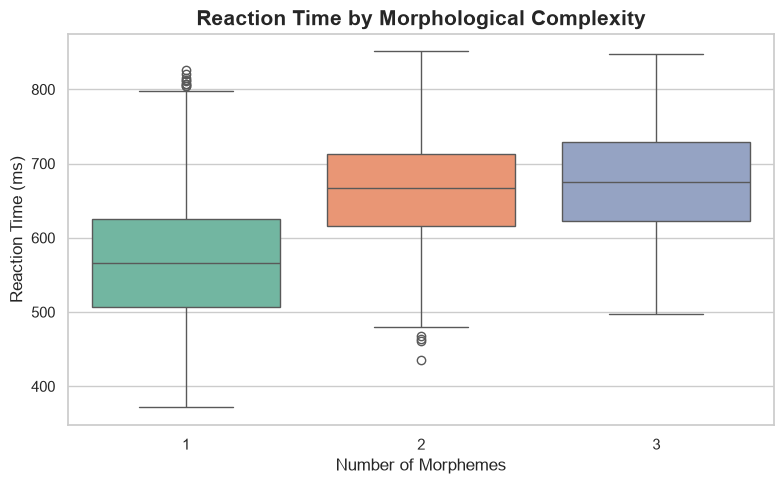

In [ ]:
# 3. Visualization: Scatter plot with regression line (Word Length vs. RT)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a scatter plot with regression line (lmplot-style using regplot for single axes)
sns.regplot(
    x='Length', y='I_Mean_RT', data=df_clean,
    scatter_kws={'alpha': 0.3, 'color': 'gray', 's': 15},
    line_kws={'color': 'red', 'linewidth': 3}
)

plt.title("Visual Word Recognition: Word Length Effect on Reaction Time", fontsize=15, fontweight='bold')
plt.xlabel("Word Length (Number of Letters)", fontsize=12)
plt.ylabel("Reaction Time (ms)", fontsize=12)

# Optional: Boxplot showing RT by Number of Morphemes
plt.figure(figsize=(8, 5))
sns.boxplot(x='N_Morph', y='I_Mean_RT', data=df_clean, palette="Set2")
plt.title("Reaction Time by Morphological Complexity", fontsize=15, fontweight='bold')
plt.xlabel("Number of Morphemes", fontsize=12)
plt.ylabel("Reaction Time (ms)", fontsize=12)

plt.tight_layout()
plt.show()